# Credit Risk and Financial Stability Analysis
## Data Preprocessing and Exploratory Data Analysis

### Objective

The objective of this notebook is to understand borrower characteristics, assess data quality, and identify patterns that may influence credit risk. These insights will support the machine learning models developed in later stages of the project.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## Load Dataset

The German Credit Dataset contains borrower demographics, financial information, and credit risk classifications.

In [2]:
df = pd.read_csv("german_credit_data.csv")

df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,residence_since,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,4,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,2,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,3,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,4,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,4,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


## Dataset Overview

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 1000
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing           

In [4]:
# Missing Value Analysis
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [8]:
cat_cols = df.select_dtypes(
    include="object"
).columns

for col in cat_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

## Credit Risk Distribution

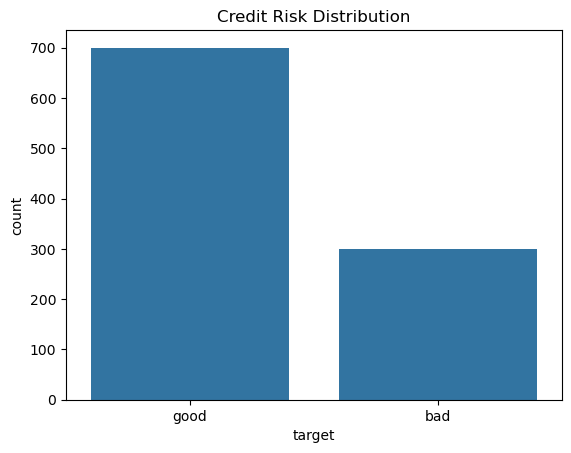

In [9]:
sns.countplot(
    x="target",
    data=df
)

plt.title(
    "Credit Risk Distribution"
)

plt.show()

## Age Distribution

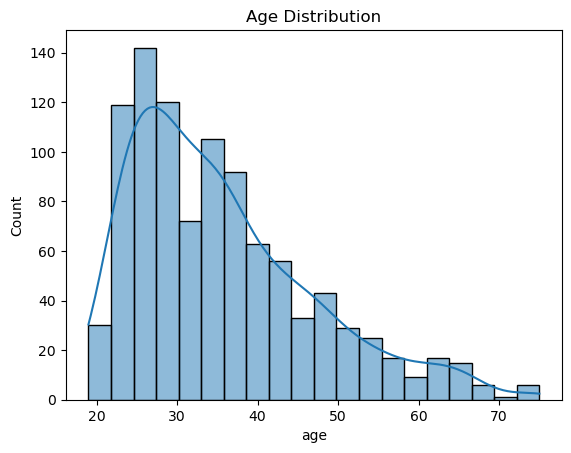

In [10]:
sns.histplot(
    df["age"],
    bins=20,
    kde=True
)

plt.title(
    "Age Distribution"
)

plt.show()

## Credit Amount Distribution

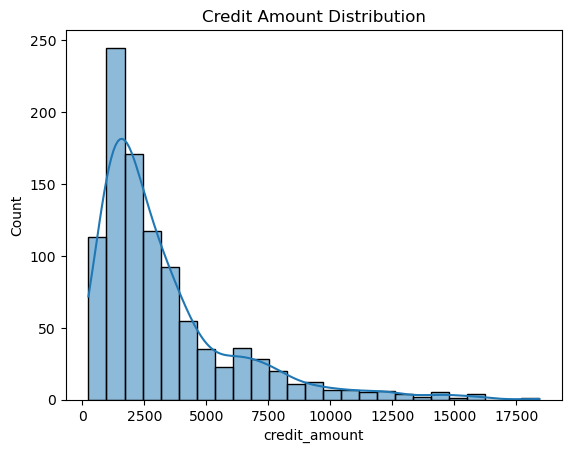

In [11]:
sns.histplot(
    df["credit_amount"],
    bins=25,
    kde=True
)

plt.title(
    "Credit Amount Distribution"
)

plt.show()

## Correlation Analysis

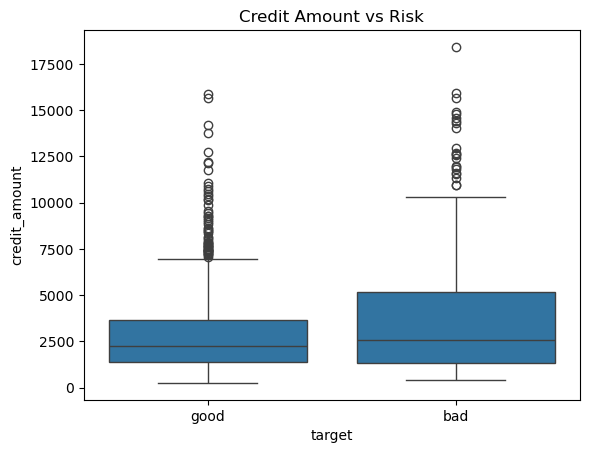

In [14]:
sns.boxplot(x='target', y='credit_amount', data=df)

plt.title("Credit Amount vs Risk")
plt.show()

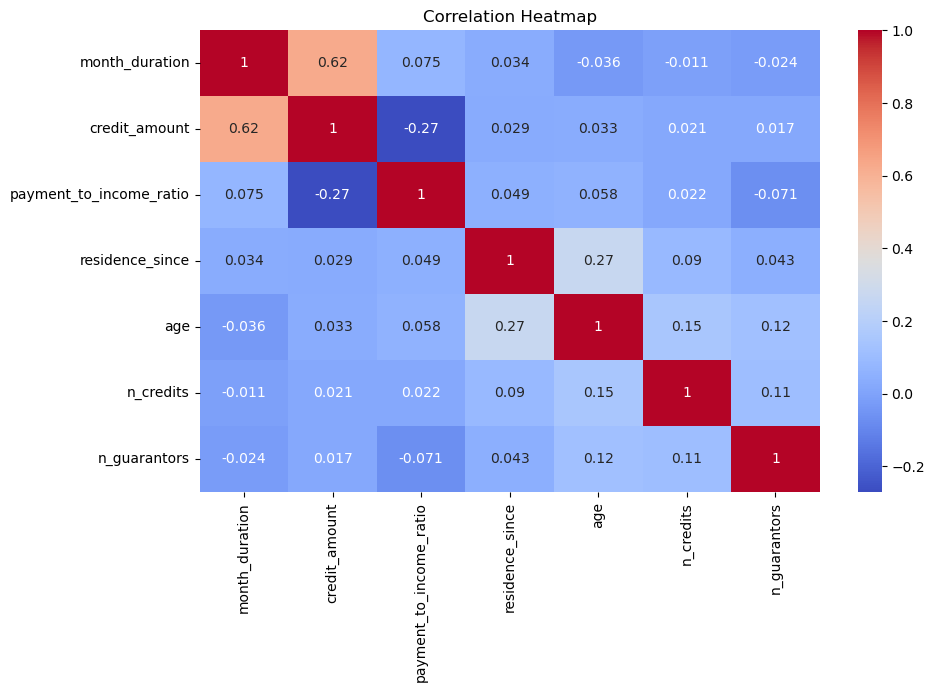

In [12]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

## Key Findings

- Data quality is suitable for machine learning analysis.
- Missing values were successfully treated.
- Credit amount and loan duration show significant variation among borrowers.
- Borrower demographics provide useful insights into lending patterns.
- The dataset is ready for feature engineering and predictive modeling.